# Plotting and Calibrating Geoprecision Thermistor chain data

This notebook provides a workflow for plotting and calibrating thermistor chain data from glacier boreholes and calibration experiments. It uses custom modules for data processing and visualization.

## Import required Libraries and Modules

In [1]:
import sys
import os

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt

# Import custom modules
from processing.process_thermistor_data import *
from calibration.thermistor_calibration import *

In [2]:
# set main calibration data dir
cal_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/calibration_data/"

# set chain calibration dir
A551FD_dir = cal_dir + "A551FD/raw/"
A551FE_dir = cal_dir + "A551FE/raw/"
A55200_dir = cal_dir + "A55200/raw/"
A55201_dir = cal_dir + "A55201/raw/"
A55202_dir = cal_dir + "A55202/raw/"
A55203_dir = cal_dir + "A55203/raw/"
A55204_dir = cal_dir + "A55204/raw/"
A55205_dir = cal_dir + "A55205/raw/"

# set maximum measurement depths
A551FE_depth = 45.0 # AH1 -> borehole depth is 50.6m
A55204_depth = 20.3 # AH2
A55205_depth = 18.3 # AH3 -> borehole depth is 58.3m
A551FD_depth = 29.0 # HL1
A55203_depth = 21.5 # HL2 
A55200_depth = 21.5 # HL3
A55201_depth = 38.3 # CH1
A55202_depth = 17.0 # CH2

# generate calibration data objects
A551FE_cal_data = ThermistorData(A551FE_dir + "A551FE_20250729123855.csv",",",A551FE_depth)   
A55204_cal_data = ThermistorData(A55204_dir + "A55204_20250729123756.csv",",",A55204_depth)   
A55205_cal_data = ThermistorData(A55205_dir + "A55205_20250729123810.csv",",",A55205_depth)   
A551FD_cal_data = ThermistorData(A551FD_dir + "A551FD_20250729123824.csv",",",A551FD_depth)
A55203_cal_data = ThermistorData(A55203_dir + "A55203_20250729123726.csv",",",A55203_depth)   
A55200_cal_data = ThermistorData(A55200_dir + "A55200_20250729123642.csv",",",A55200_depth)   
A55201_cal_data = ThermistorData(A55201_dir + "A55201_20250729123655.csv",",",A55201_depth)   
A55202_cal_data = ThermistorData(A55202_dir + "A55202_20250729123712.csv",",",A55202_depth)   


## Load thermistor chain data

In [3]:
# get calibration data for each thermistor chain
A551FD_cal_df = A551FD_cal_data.get_chain_data('28.07.2025 13:30:00','28.07.2025 14:30:00')
A551FE_cal_df = A551FE_cal_data.get_chain_data('28.07.2025 14:20:00','28.07.2025 15:30:00')
A55200_cal_df = A55200_cal_data.get_chain_data('28.07.2025 13:20:00','28.07.2025 14:30:00')
A55201_cal_df = A55201_cal_data.get_chain_data('28.07.2025 12:00:00','28.07.2025 13:30:00')
A55202_cal_df = A55202_cal_data.get_chain_data('28.07.2025 16:30:00','28.07.2025 17:30:00')
A55203_cal_df = A55203_cal_data.get_chain_data('28.07.2025 10:45:00','28.07.2025 11:45:00')
A55204_cal_df = A55204_cal_data.get_chain_data('28.07.2025 14:40:00','28.07.2025 15:40:00')
A55205_cal_df = A55205_cal_data.get_chain_data('28.07.2025 15:50:00','28.07.2025 16:50:00')


## Calculate 0-degree offsets
Measurements in 0 degree alcohol bath. The final offsets will be calculated from the bath temperature measured by a high-precision thermometer.

In [4]:
# calculate zero degree offsets
all_offsets = {
    "A551FD": calculate_chain_zero_degree_offsets(A551FD_cal_df),
    "A551FE": calculate_chain_zero_degree_offsets(A551FE_cal_df),
    "A55200": calculate_chain_zero_degree_offsets(A55200_cal_df),
    "A55201": calculate_chain_zero_degree_offsets(A55201_cal_df),
    "A55202": calculate_chain_zero_degree_offsets(A55202_cal_df),
    "A55203": calculate_chain_zero_degree_offsets(A55203_cal_df),
    "A55204": calculate_chain_zero_degree_offsets(A55204_cal_df),
    "A55205": calculate_chain_zero_degree_offsets(A55205_cal_df),
}

# read high-precision thermometer data
hp_thermometer_dir = cal_dir + "/high_precision_thermometer.csv" # set path to high-precision thermometer data
hp_thermometer_df = pd.read_csv(hp_thermometer_dir, sep=';', header=0, decimal=',')

# apply correction from high-precision thermometer --> gives most accurate temperature of alcohol bath from which the offsets can be calculated
corrected_offsets = {}
for chain, offsets in all_offsets.items():
    bath_temp = hp_thermometer_df.loc[hp_thermometer_df['logger'] == chain, 'average temp'].values[0]
    corrected_offsets[chain] = {k: v - bath_temp for k, v in offsets.items()}

In [5]:
all_offsets['A551FD']
corrected_offsets['A551FD']

{'#1': np.float64(0.009434999999999999),
 '#2': np.float64(-0.0065669999999999895),
 '#3': np.float64(0.016973000000000016),
 '#4': np.float64(0.030327999999999994),
 '#5': np.float64(-0.040576),
 '#6': np.float64(-0.003681999999999991),
 '#7': np.float64(0.020939000000000013),
 '#8': np.float64(0.025057999999999997),
 '#9': np.float64(0.006987999999999994),
 '#10': np.float64(0.013782000000000016)}

## Plot Thermistor Chain Data

In [6]:
# set main icetemp data dir
icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/temperature_data/"


# set output dir for figures
output_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/"

# set chain data dir
A551FE_dir = icetemp_dir + "A551FE/raw/" # AH1
A55204_dir = icetemp_dir + "A55204/raw/" # AH2
A55205_dir = icetemp_dir + "A55205/raw/" # AH3
A551FD_dir = icetemp_dir + "A551FD/raw/" # HL1
A55203_dir = icetemp_dir + "A55203/raw/" # HL2
A55200_dir = icetemp_dir + "A55200/raw/" # HL3
A55201_dir = icetemp_dir + "A55201/raw/A55201_20250819105833.csv" # CH1
A55202_dir = icetemp_dir + "A55202/raw/A55202_20250819111557.csv" # CH2

# set path to current depth file
depth_ch1 = icetemp_dir + "../thermistor_settings/thermistor_settings_ch1.csv"
depth_ch2 = icetemp_dir + "../thermistor_settings/thermistor_settings_ch2.csv"

# generate chain plotting objects per borehole
CH1 = ThermistorDataPlotter(A55201_dir, ",")
CH2 = ThermistorDataPlotter(A55202_dir, ",")

In [7]:
# apply chain offsets
CH1.data = apply_chain_offsets(CH1.data, calibration.thermistor_chains_0deg_references.A55201_offsets)
CH2.data = apply_chain_offsets(CH2.data, calibration.thermistor_chains_0deg_references.A55202_offsets)


AttributeError: 'ThermistorDataPlotter' object has no attribute 'data'

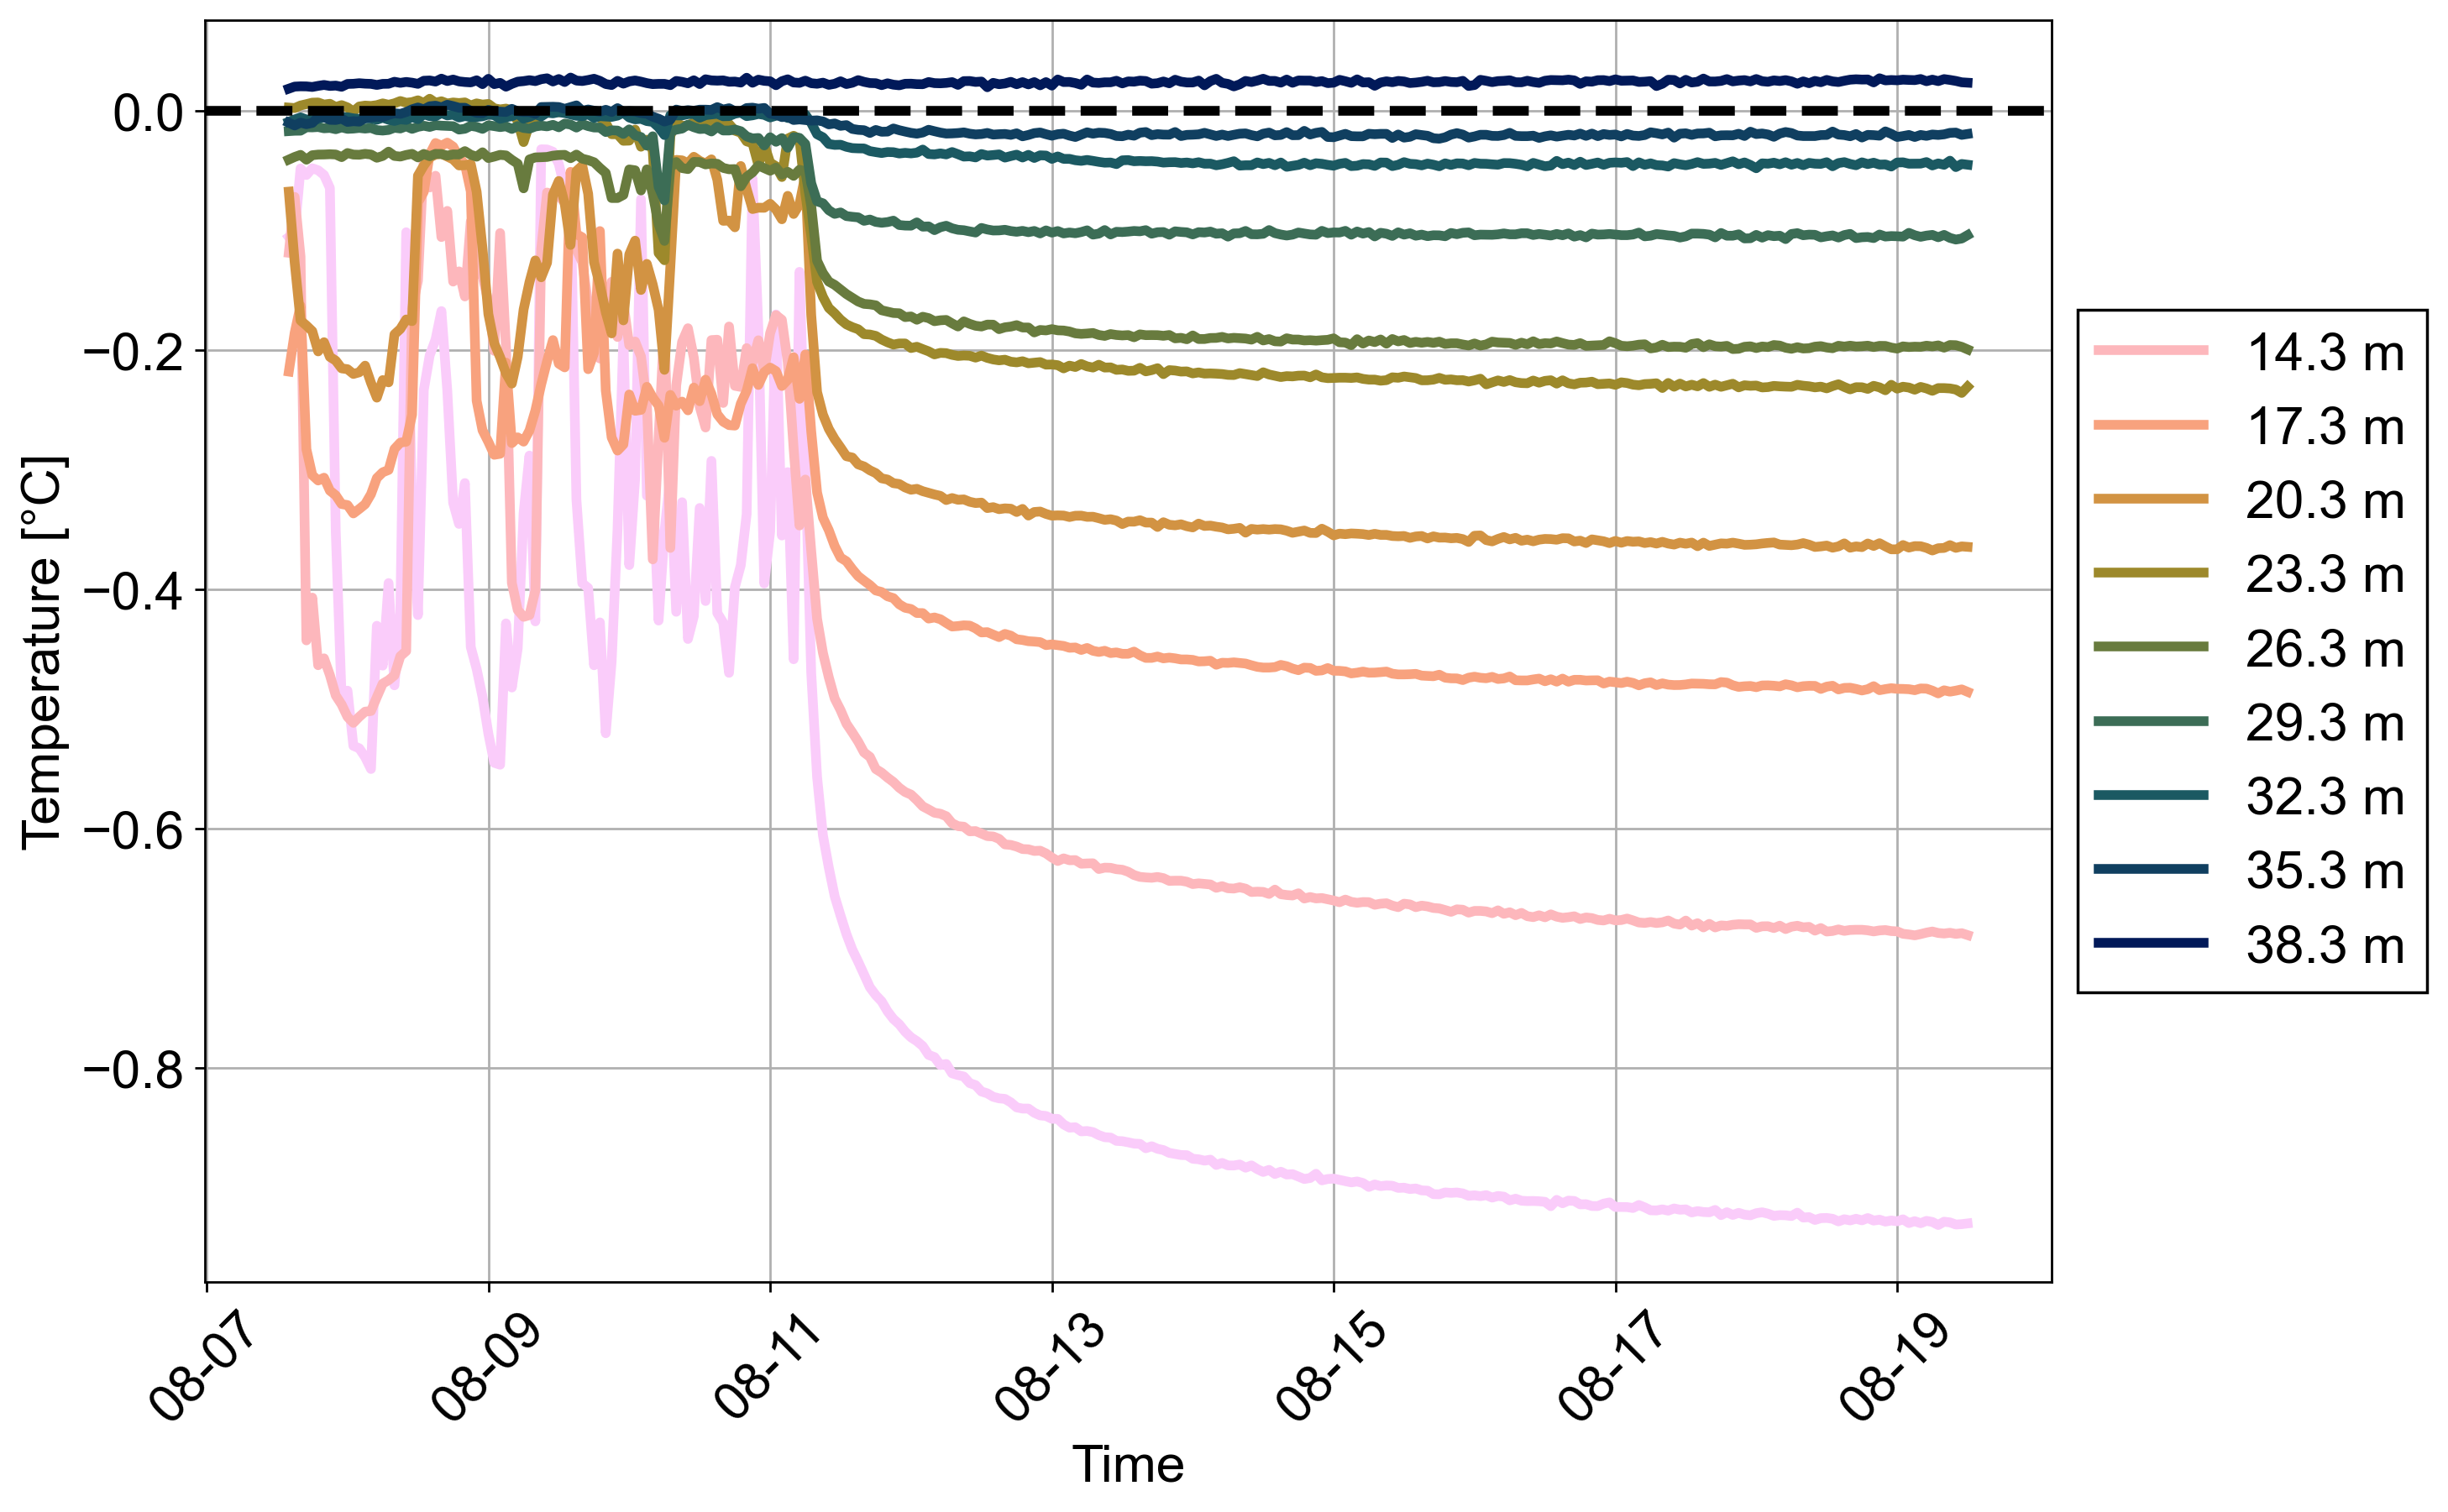

In [7]:
CH1.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', output_dir + "CH1_full_chain.png", depth_file=depth_ch1)

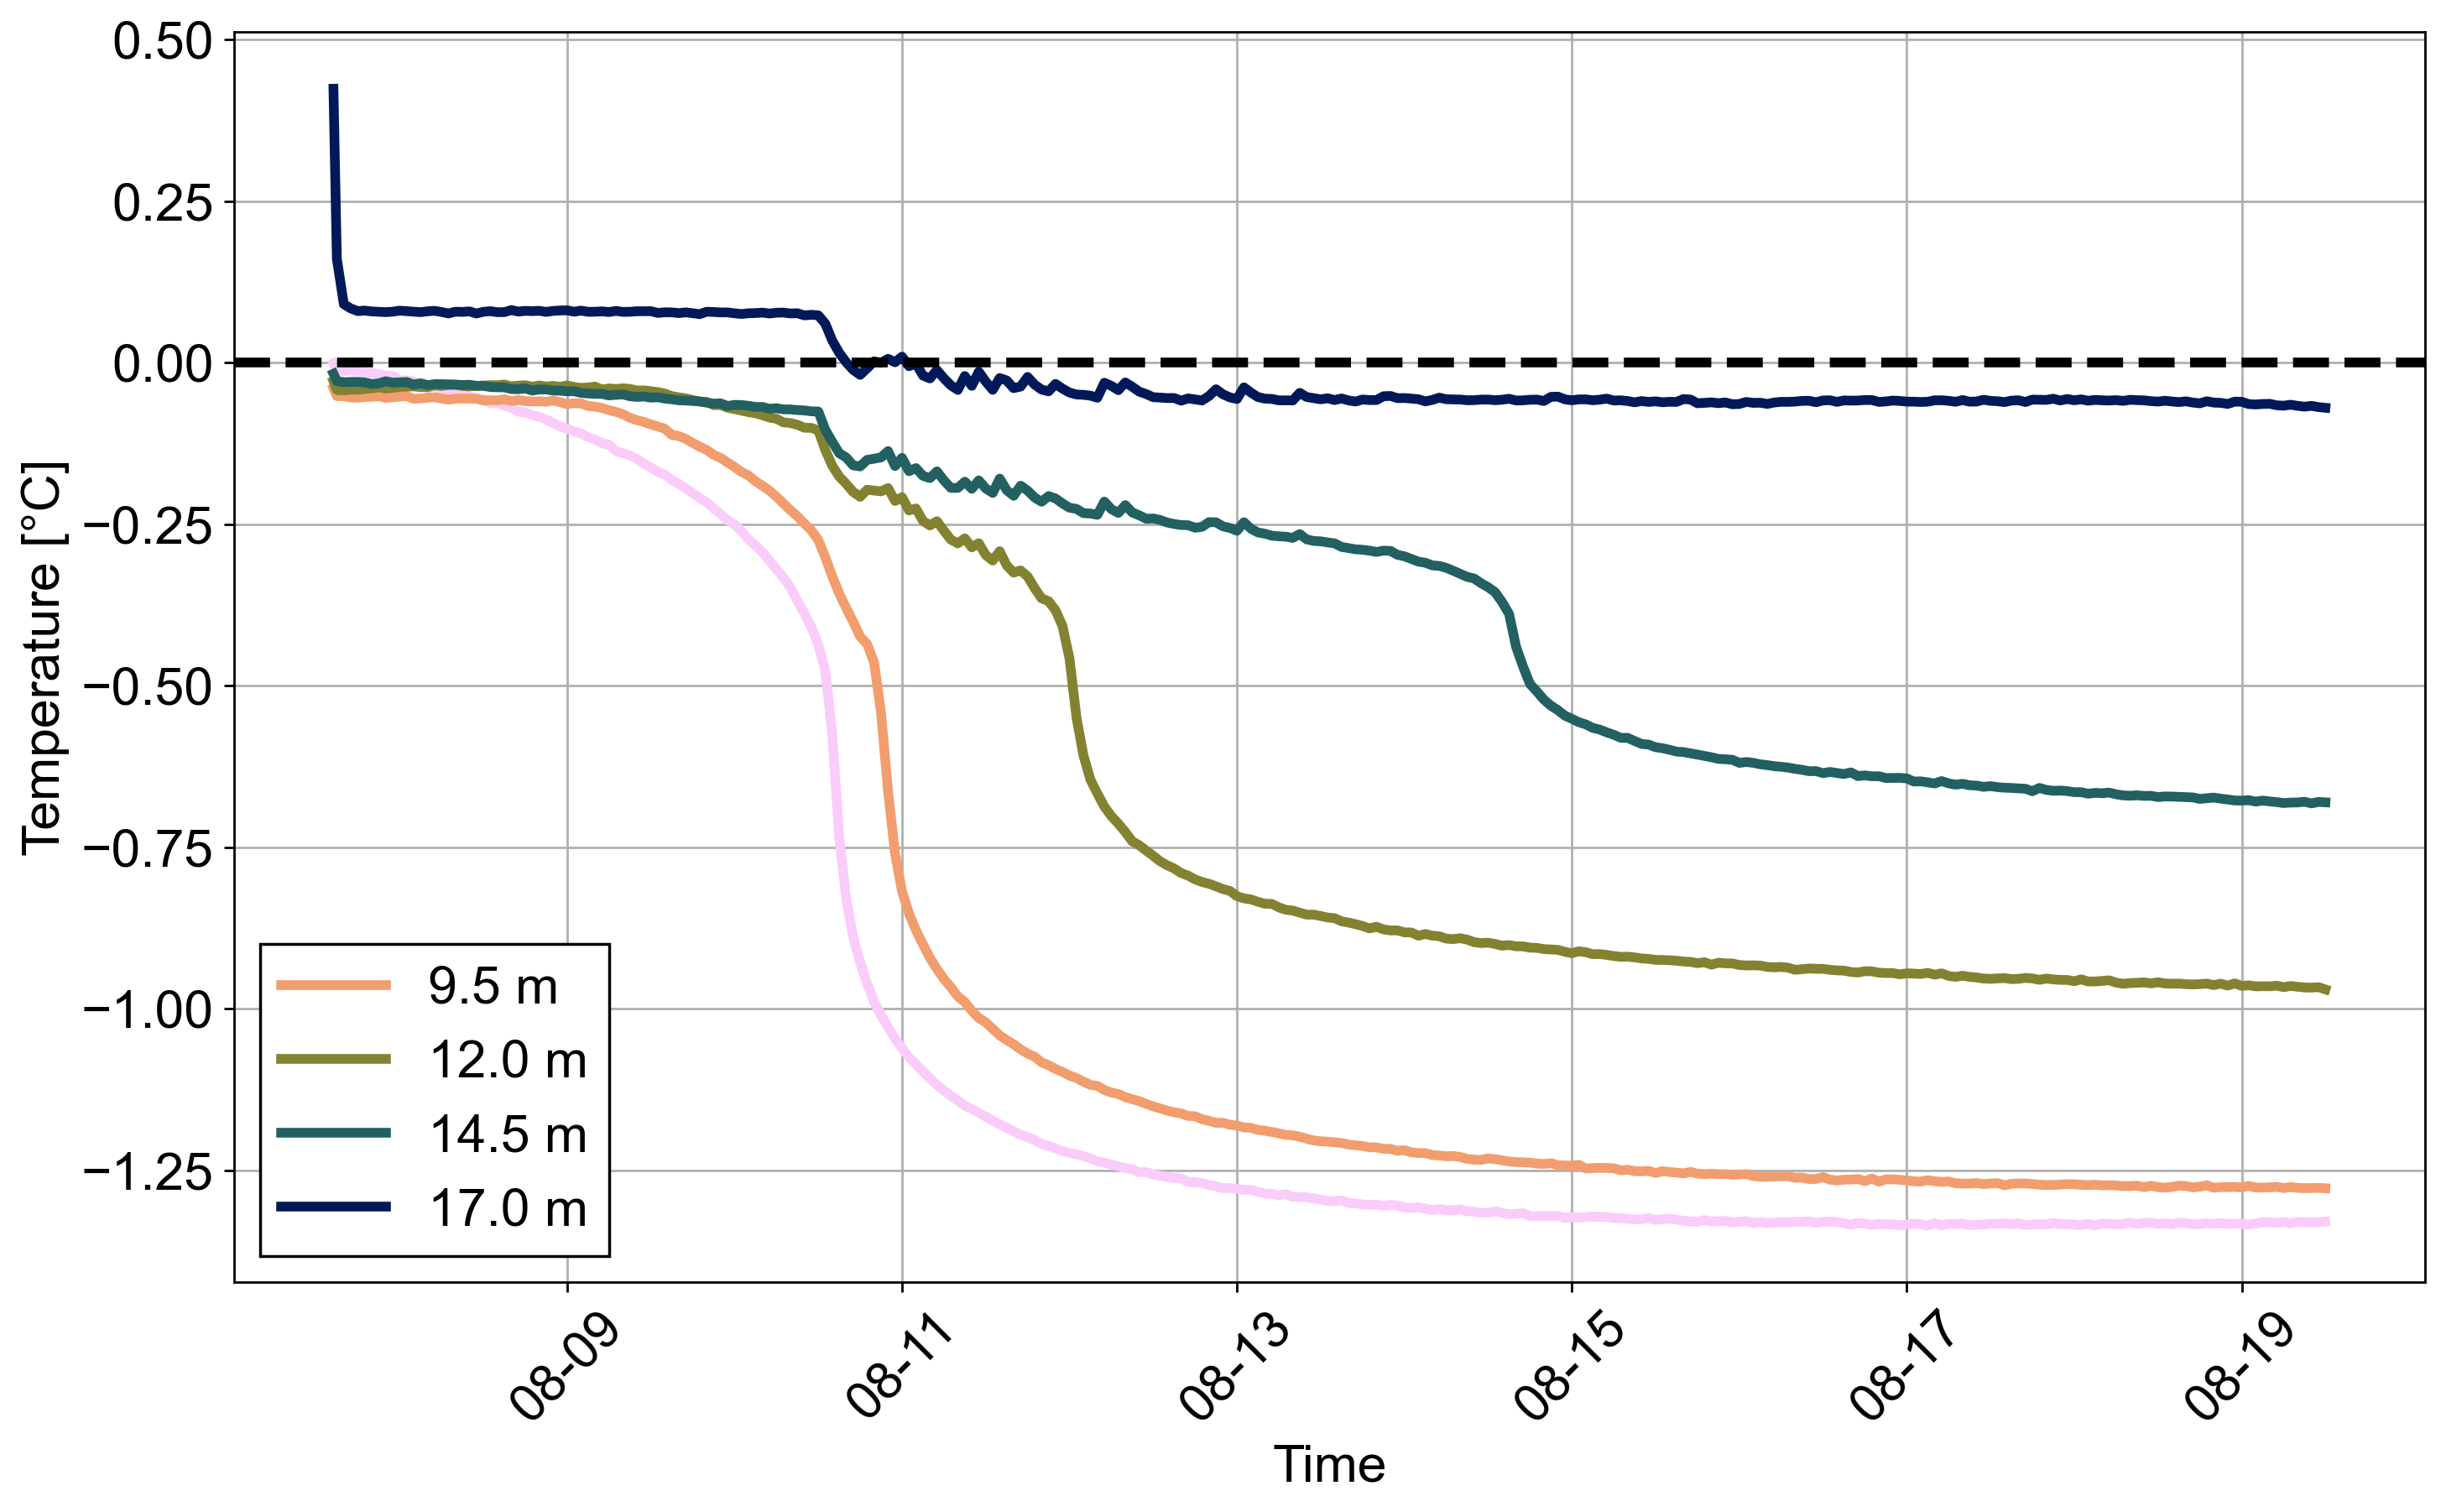

In [8]:
CH2.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', output_dir + "CH2_full_chain.png", depth_file=depth_ch2)

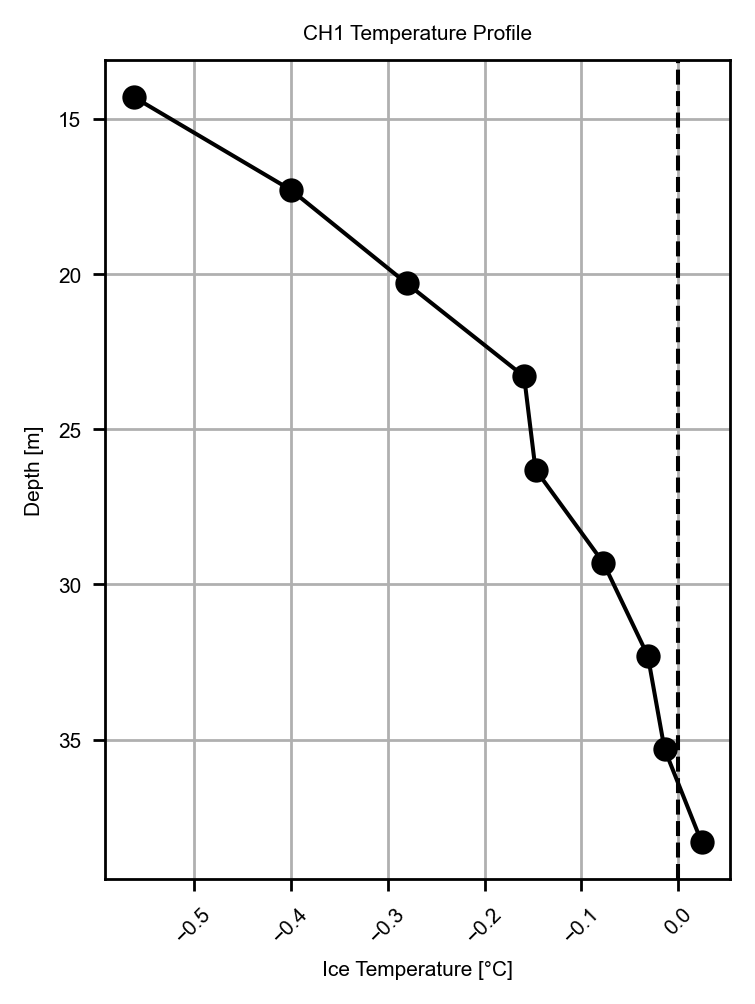

In [9]:
CH1.plot_stabilized_temperature_profile(
    start_time='07.08.2025 13:30:00',
    end_time='19.08.2025 13:00:00',
    depth_file=depth_ch1,
    savepath=output_dir + "CH1_temperature_profile.png",
    title="CH1 Temperature Profile"
)

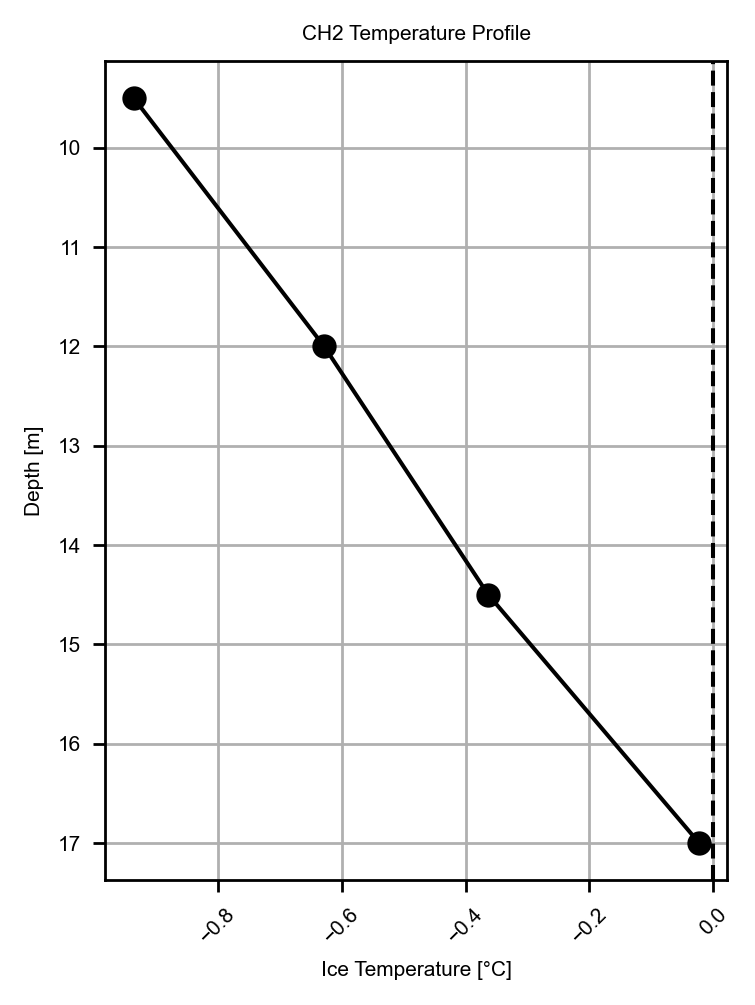

In [10]:
CH2.plot_stabilized_temperature_profile(
    start_time='07.08.2025 13:30:00',
    end_time='19.08.2025 13:00:00',
    depth_file=depth_ch2,
    savepath=output_dir + "CH2_temperature_profile.png",
    title="CH2 Temperature Profile"
)

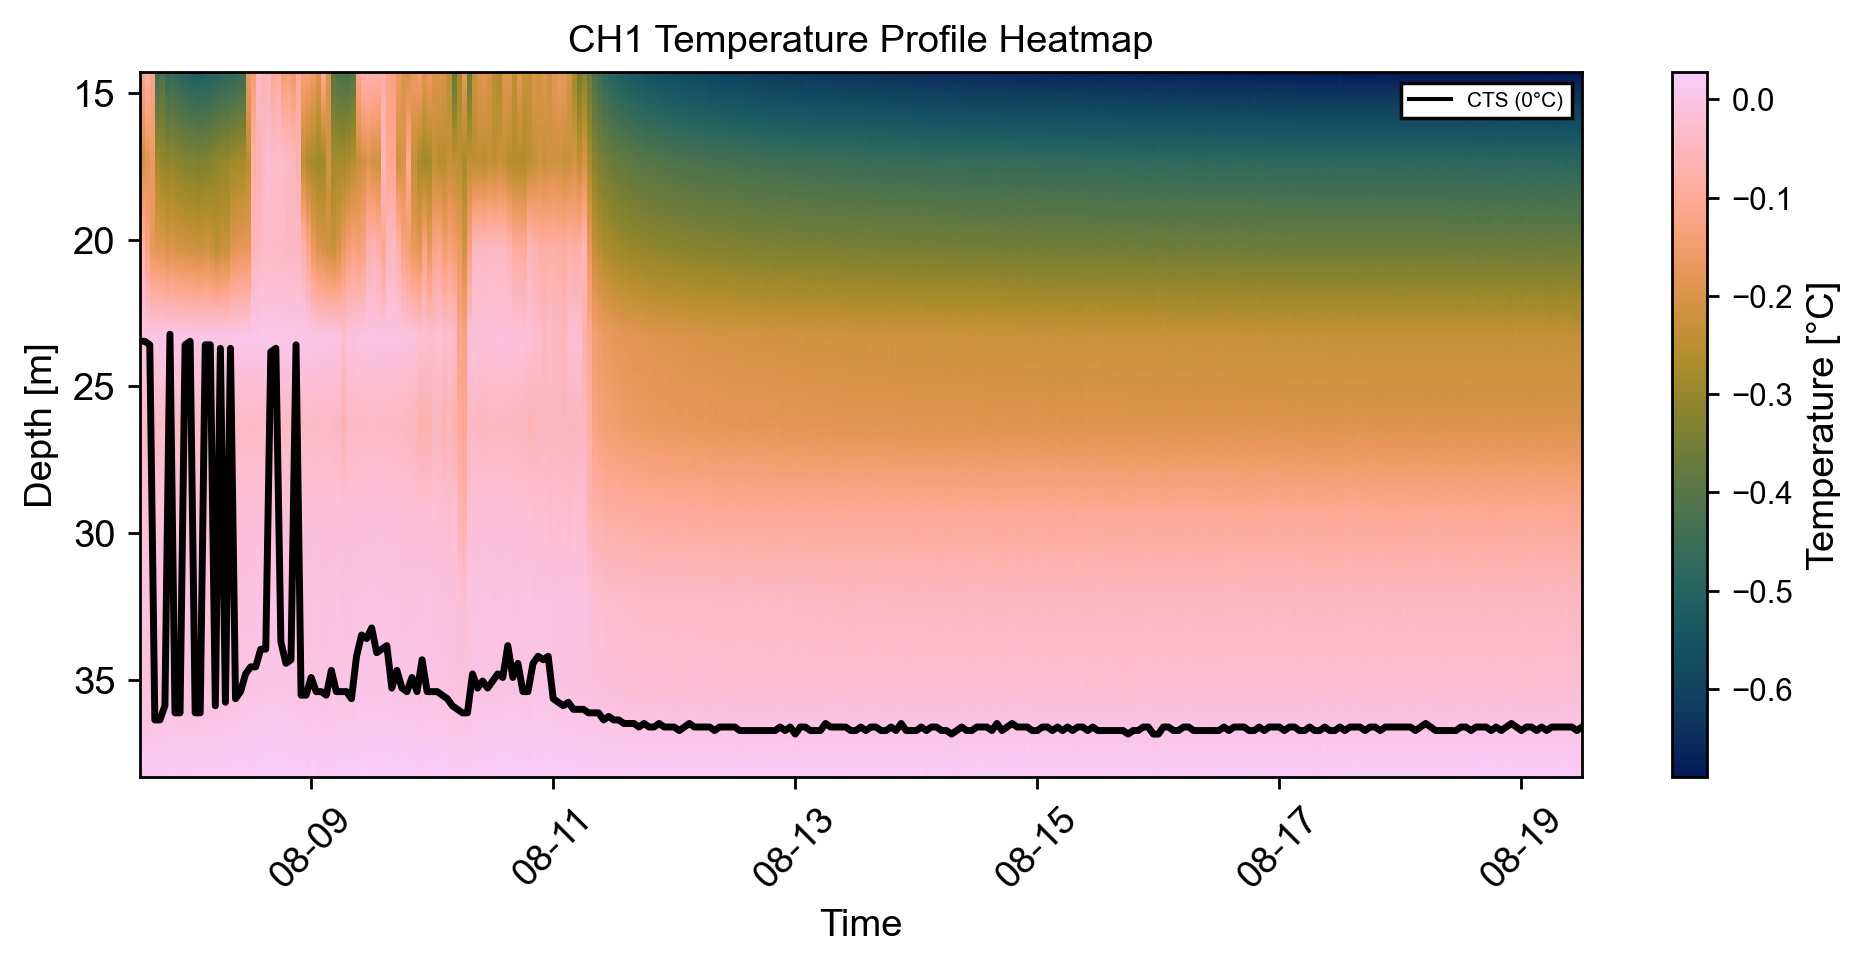

In [11]:
CH1.plot_temperature_heatmap(
    start_time='07.08.2025 13:30:00',
    end_time='19.08.2025 13:00:00',
    depth_file=depth_ch1,
    savepath=output_dir + "CH1_heatmap_cts.png",
    title="CH1 Temperature Profile Heatmap"
)

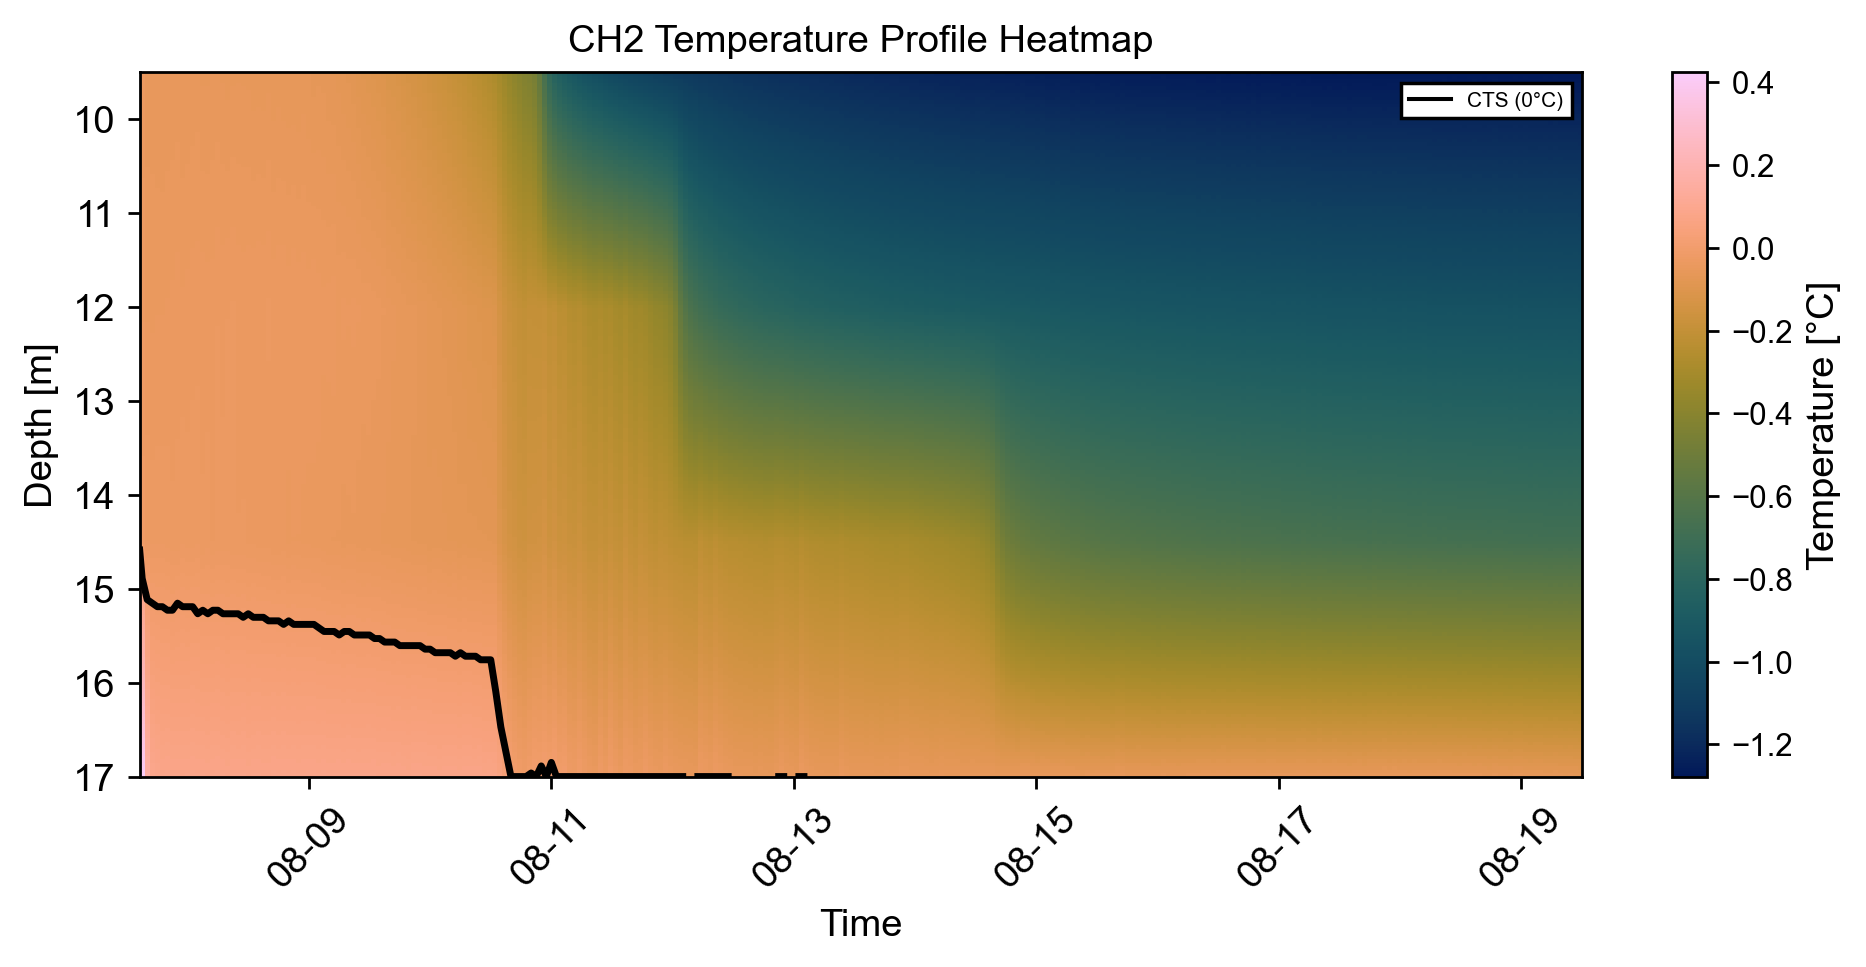

In [12]:
CH2.plot_temperature_heatmap(
    start_time='07.08.2025 13:30:00',
    end_time='19.08.2025 13:00:00',
    depth_file=depth_ch2,
    savepath=output_dir + "CH2_heatmap_cts.png",
    title="CH2 Temperature Profile Heatmap"
)